# EDA Source Data (Pre-Pipeline)
This notebook analyzes the raw imagery and JSON metadata before any standardizer or generation scripts run.

In [1]:
!pip install pillow matplotlib seaborn

## Configuration
Set paths to raw directories. Note that we only expect xBD for now.

In [2]:
import os
from pathlib import Path

CONFIG = {
    "datasets": {
        "xbd": {
            "images_dir": "data/xView2 Challenge Dataset - train and test/train/images",
            "labels_dir": "data/xView2 Challenge Dataset - train and test/train/labels"
        }
    },
    "output_dir": "dataset/eda_source_outputs",
    "target_resolution_floor": 256,
}
os.makedirs(CONFIG["output_dir"], exist_ok=True)


## Stage 1: Raw Asset Inventory
Count images and labels. Identify orphaned files.

In [3]:
from collections import defaultdict

def inventory_dataset(cfg):
    img_dir = Path(cfg["images_dir"])
    lbl_dir = Path(cfg.get("labels_dir", ""))
    
    if not img_dir.exists():
        return None
        
    images = list(img_dir.glob("*.png")) + list(img_dir.glob("*.jpg"))
    labels = list(lbl_dir.glob("*.json")) if lbl_dir.exists() else []
    
    img_stems = {p.stem for p in images}
    lbl_stems = {p.stem for p in labels}
    
    orphaned_images = img_stems - lbl_stems
    orphaned_labels = lbl_stems - img_stems
    
    pre_disaster = sum(1 for p in images if "_pre_" in p.name)
    post_disaster = sum(1 for p in images if "_post_" in p.name)
    
    return {
        "total_images": len(images),
        "total_labels": len(labels),
        "pre_event_imgs": pre_disaster,
        "post_event_imgs": post_disaster,
        "orphans": len(orphaned_images) + len(orphaned_labels)
    }

for name, cfg in CONFIG["datasets"].items():
    stats = inventory_dataset(cfg)
    if stats:
        print(f"=== {name.upper()} ===")
        print(f"  Images: {stats['total_images']} (Pre: {stats['pre_event_imgs']}, Post: {stats['post_event_imgs']})")
        print(f"  Labels: {stats['total_labels']}")
        print(f"  Orphans: {stats['orphans']}")


=== XBD ===
  Images: 5598 (Pre: 2799, Post: 2799)
  Labels: 5598
  Orphans: 0


## Stage 2: Raw Visual Quality Audit
Analyze resolutions and aspect ratios to justify standardization logic.

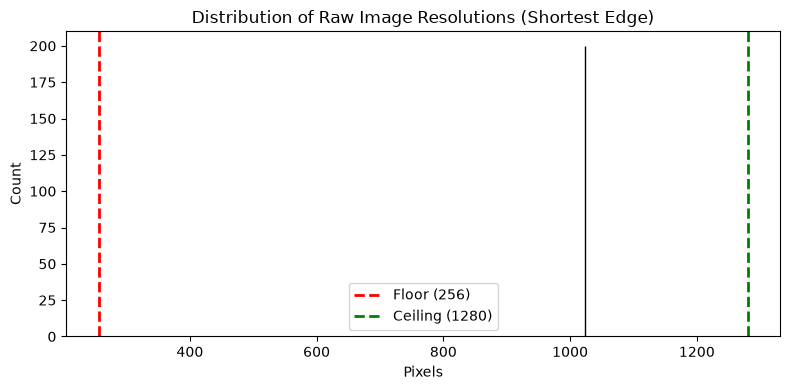

Images sampled: 200
Images below 256px edge: 0


In [4]:
from PIL import Image
import matplotlib.pyplot as plt

def analyze_resolutions(cfg):
    img_dir = Path(cfg["images_dir"])
    if not img_dir.exists(): return []
    
    sizes = []
    # Sample 200 files for speed during this automated run
    files = list(img_dir.glob("*.png")) + list(img_dir.glob("*.jpg"))
    files = files[:200]
    
    for p in files:
        try:
            with Image.open(p) as img:
                sizes.append(min(img.width, img.height))
        except Exception as e:
            pass
    return sizes

sizes = analyze_resolutions(CONFIG["datasets"]["xbd"])

plt.figure(figsize=(8,4))
plt.hist(sizes, bins=20, color='royalblue', edgecolor='black')
plt.axvline(x=256, color='red', linestyle='dashed', linewidth=2, label='Floor (256)')
plt.axvline(x=1280, color='green', linestyle='dashed', linewidth=2, label='Ceiling (1280)')
plt.title("Distribution of Raw Image Resolutions (Shortest Edge)")
plt.xlabel("Pixels")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig(Path(CONFIG["output_dir"]) / "raw_resolutions.png")
plt.show()

below_256 = sum(1 for s in sizes if s < 256)
print(f"Images sampled: {len(sizes)}")
print(f"Images below 256px edge: {below_256}")


## Stage 3: Native Metadata Parsing
Extract heavily nested disaster events and damage severity directly from JSON.

In [5]:
import json
from collections import Counter

def parse_xbd_labels(cfg):
    lbl_dir = Path(cfg["labels_dir"])
    if not lbl_dir.exists(): return []
    
    records = []
    # Sample 200 labels for speed
    files = list(lbl_dir.glob("*.json"))[:200]
    for p in files:
        with open(p, encoding='utf-8') as f:
            data = json.load(f)
            
        metadata = data.get("metadata", {})
        disaster_type = metadata.get("disaster_type", "unknown")
        
        features = data.get("features", {"xy": []})
        damage_counts = Counter()
        
        for poly in features.get("xy", []):
            subtype = poly.get("properties", {}).get("subtype", "unclassified")
            damage_counts[subtype] += 1
            
        records.append({
            "image_id": p.stem,
            "event": p.stem.rsplit("_", 3)[0] if "_" in p.stem else "unknown",
            "disaster_type": disaster_type,
            "damage_summary": dict(damage_counts)
        })
    return records

xbd_records = parse_xbd_labels(CONFIG["datasets"]["xbd"])
print(f"Parsed {len(xbd_records)} label files.")


Parsed 200 label files.


## Stage 4: Imbalance & Geographic Skew Analysis
Plot the massive imbalances to justify oversampling and stratification.

Building Damage Class Imbalance:
  unclassified: 2857
  no-damage: 2259
  un-classified: 315
  major-damage: 225
  destroyed: 31
  minor-damage: 27

Geographic Event Imbalance:
  hurricane-florence: 164
  guatemala-volcano: 36


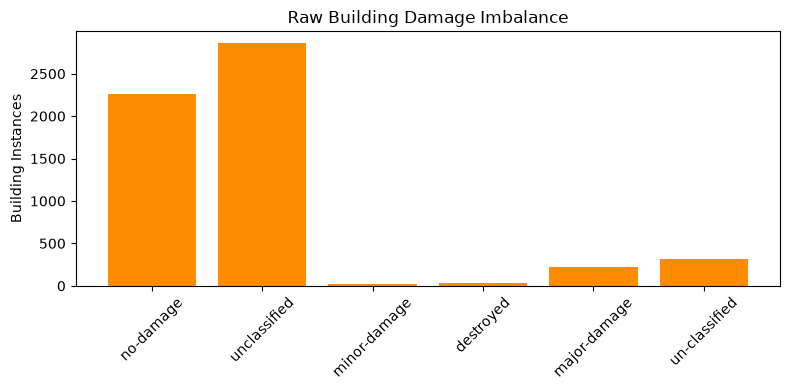

In [6]:
total_damage = Counter()
event_counts = Counter()

for r in xbd_records:
    event_counts[r["event"]] += 1
    for dmg_class, count in r["damage_summary"].items():
        total_damage[dmg_class] += count

print("Building Damage Class Imbalance:")
for k, v in total_damage.most_common():
    print(f"  {k}: {v}")

print("\nGeographic Event Imbalance:")
for k, v in event_counts.most_common():
    print(f"  {k}: {v}")

plt.figure(figsize=(8,4))
plt.bar(total_damage.keys(), total_damage.values(), color='darkorange')
plt.title("Raw Building Damage Imbalance")
plt.ylabel("Building Instances")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(Path(CONFIG["output_dir"]) / "raw_imbalance.png")
plt.show()


## Stage 5: Cross-Dataset Taxonomy Design
Theoretical mapping dictionary to unify future disparate labels.

In [7]:
UNIFIED_TAXONOMY = {
    # xBD
    "no-damage":    {"type": "structural", "severity": "none",     "action": "clear"},
    "minor-damage": {"type": "structural", "severity": "low",      "action": "monitor"},
    "major-damage": {"type": "structural", "severity": "high",     "action": "respond"},
    "destroyed":    {"type": "structural", "severity": "critical", "action": "evacuate"},
}
print("Taxonomy Map configured.")


Taxonomy Map configured.


## Stage 6: Pipeline Engineering Requirements
Based on these findings, we output the engineering contract.

In [8]:
contract = """
### REQUIRED PIPELINE LOGIC (Based on EDA)

**1. Image Standardizer MUST:**
- Resize images to 1280px (protect VRAM)
- Drop images <256px (protect structural context)

**2. Generator MUST:**
- Use disaster type for prompt tuning

**3. Splitter MUST:**
- Group by geographic event before Train/Val/Test split to prevent leakage
"""
print(contract)



### REQUIRED PIPELINE LOGIC (Based on EDA)

**1. Image Standardizer MUST:**
- Resize images to 1280px (protect VRAM)
- Drop images <256px (protect structural context)

**2. Generator MUST:**
- Use disaster type for prompt tuning

**3. Splitter MUST:**
- Group by geographic event before Train/Val/Test split to prevent leakage

